# Exploratory Data Analysis (EDA)

## Project
Netflix Content Analytics

## Sprint
Sprint 3 – Exploratory Data Analysis

## Objective

The objective of this notebook is to explore Netflix's content catalogue using the cleaned dataset and answer business questions that support strategic decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path= '/content/drive/MyDrive/project_source_files/netflix_titles_cleaned.csv'
df= pd.read_csv(file_path)
df.head()


,Show Id,Type,Title,Director,Cast,Country,Date Added,Release Year,Rating,Duration,Listed In,Description
0,S1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25 00:00:00,2020,Pg-13,90 Min,Documentaries,"As Her Father Nears The End Of His Life, Filmm..."
1,S2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After Crossing Paths At A Party, A Cape Town T..."
2,S3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To Protect His Family From A Powerful Drug Lor...
3,S4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24 00:00:00,2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, Flirtations And Toilet Talk Go Down Amo..."
4,S5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In A City Of Coaching Centers Known To Train I...


# Business Questions

The following questions will guide this exploratory analysis.

1. What percentage of Netflix's catalogue consists of Movies versus TV Shows?

2. How has Netflix's content library changed over time?

3. Which countries contribute the most content?

4. What are the most common content ratings?

5. Which genres dominate the catalogue?

6. What is the distribution of movie durations?

7. Which directors appear most frequently?

8. Which years produced the most content?

In [4]:
# Business Question 1:
# How many movies and TV shows are available on Netflix?
content_types = df["Type"].value_counts().reset_index(name="Number of Titles")
content_types

,Type,Number of Titles
0,Movie,6131
1,Tv Show,2676


/tmp/ipykernel_5715/1917177122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=content_types, x="Type", y="Number of Titles", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


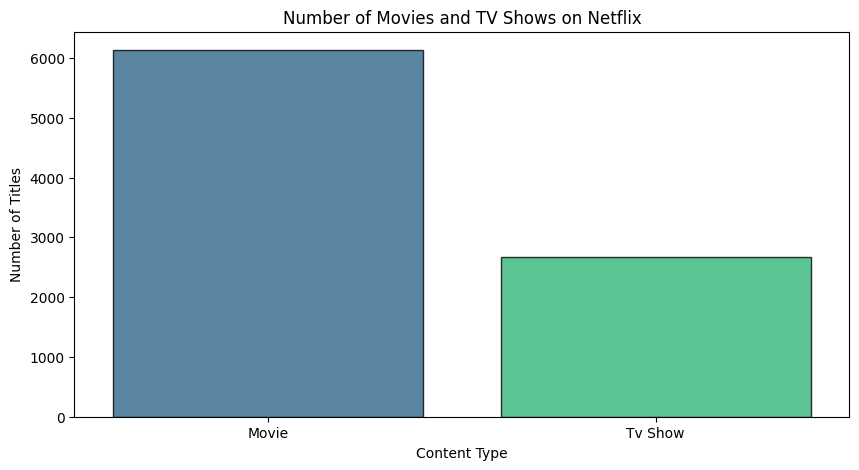

In [5]:
# Bar chart to visualize the number of movies and TV shows
plt.figure(figsize=(10,5))
sns.barplot(data=content_types, x="Type", y="Number of Titles", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Number of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

## Business Insight

Movies represent the majority of Netflix's catalogue, indicating that the platform has historically invested more heavily in film content than television series. Based on the Dataset the 70% of the content are movies and the rest 30% represents TV shows. This suggests that movies remain a core component of Netflix's content strategy.

In [6]:
# Calculate the percentage of each content type
content_types["Percentage"]= content_types["Number of Titles"]/content_types["Number of Titles"].sum()*100
content_types

,Type,Number of Titles,Percentage
0,Movie,6131,69.615079
1,Tv Show,2676,30.384921


In [7]:
# Business Question #2
# How has Netflix's content library changed over time?
df["Date Added"].head()


,Date Added
0,2021-09-25 00:00:00
1,2021-09-24 00:00:00
2,2021-09-24 00:00:00
3,2021-09-24 00:00:00
4,2021-09-24 00:00:00


In [8]:

# Drop rows with missing values in the "Date Added" column
df["Date Added"]=df["Date Added"].replace("Unknown", np.nan)
df=df.dropna(subset=["Date Added"])
df.isnull().sum()

,0
Show Id,0
Type,0
Title,0
Director,0
Cast,0
Country,0
Date Added,0
Release Year,0
Rating,0
Duration,0


In [9]:
# Extract the Year from the "Date Added" column and create a new column "Year Added"
df["Year Added"]= pd.to_datetime(df["Date Added"]).dt.year
df[["Date Added", "Year Added"]].head()

,Date Added,Year Added
0,2021-09-25 00:00:00,2021
1,2021-09-24 00:00:00,2021
2,2021-09-24 00:00:00,2021
3,2021-09-24 00:00:00,2021
4,2021-09-24 00:00:00,2021


In [10]:
# Count Contents Added Per Year
titles_per_year = df["Year Added"].value_counts().sort_index().reset_index(name="Number of Contents")
titles_per_year

,Year Added,Number of Contents
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


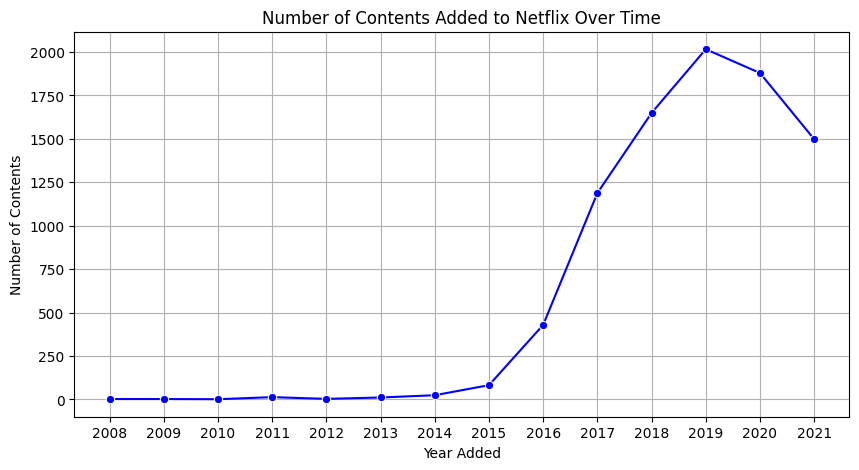

In [26]:
# plot the number of contents added to Netflix over time using a line chart
plt.figure(figsize=(10,5))
sns.lineplot(data=titles_per_year, x="Year Added", y="Number of Contents", marker="o", color="blue")
plt.title("Number of Contents Added to Netflix Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Contents")
plt.xticks(titles_per_year["Year Added"].unique())
plt.grid()
plt.show()

## Business Insight

Netflix experienced significant growth in the number of titles added to its catalogue over several years, reaching a peak before showing a decline in later years. This pattern may reflect changes in content acquisition strategy, licensing agreements, or production schedules. Additional business context would be needed to determine the exact cause.

In [12]:
# Business Question #3
# Which countries produce the most content for Netflix?
df["Country"].value_counts().head(20).reset_index(name="Number of Titles")

,Country,Number of Titles
0,United States,2812
1,India,972
2,Unknown,830
3,United Kingdom,418
4,Japan,244
5,South Korea,199
6,Canada,181
7,Spain,145
8,France,124
9,Mexico,110


In [13]:
# Split the "Country" column into a list of countries for each title 
# Explode the "Country" column to create a new row for each country associated with a title
country_df=df.copy()
country_df["Country"] = country_df["Country"].str.split(",")
country_df = country_df.explode("Country")
country_df["Country"] = country_df["Country"].str.strip()  # Remove Extra Spaces


In [14]:
# Calculate the top 15 countries producing content for Netflix
top_countries=country_df["Country"].value_counts().head(15).reset_index(name="Number of Contents")
top_countries

,Country,Number of Contents
0,United States,3684
1,India,1046
2,Unknown,830
3,United Kingdom,805
4,Canada,445
5,France,393
6,Japan,317
7,Spain,232
8,South Korea,231
9,Germany,226


/tmp/ipykernel_5715/291299194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, y="Country", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


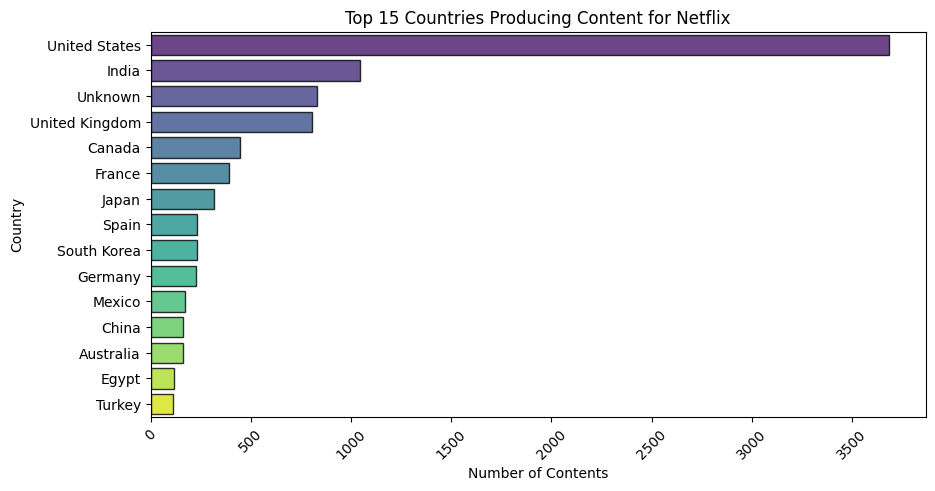

In [15]:
# Bar chart to visualize the top 15 countries producing content for Netflix
plt.figure(figsize=(10,5))
sns.barplot(data=top_countries, y="Country", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 15 Countries Producing Content for Netflix")
plt.xlabel("Number of Contents")
plt.ylabel("Country")
plt.xticks(rotation=45)
plt.show()

### Observation

The United States contributes the largest number of titles in Netflix's catalogue, followed by several other countries. The distribution indicates that a relatively small number of countries account for a significant share of the available content.

In [16]:
# Business Question #4
# What are the most common ratings for Netflix content?
df_ratings =df.copy()
df_ratings["Rating"]= df_ratings["Rating"].str.strip()
top_10_rating = df_ratings["Rating"].value_counts().head(10).reset_index(name="Number of Contents")
top_10_rating


,Rating,Number of Contents
0,Tv-Ma,3205
1,Tv-14,2157
2,Tv-Pg,861
3,R,799
4,Pg-13,490
5,Tv-Y7,333
6,Tv-Y,306
7,Pg,287
8,Tv-G,220
9,Nr,79


/tmp/ipykernel_5715/3074949563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_rating, x="Rating", y="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


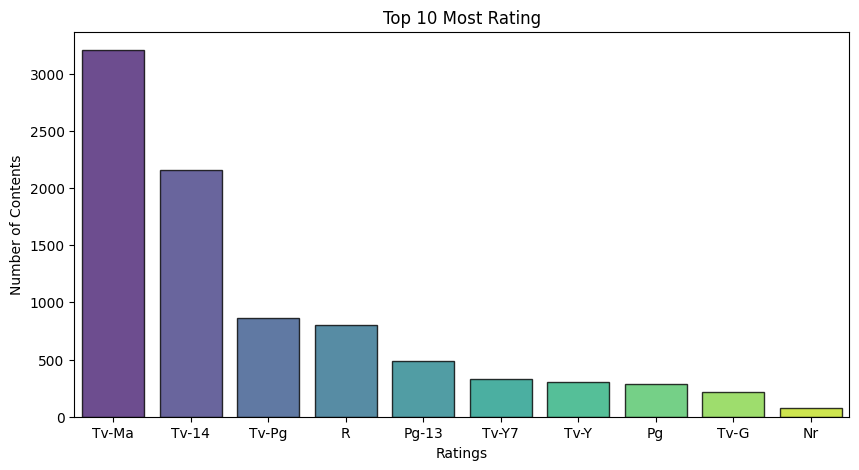

In [23]:
# plot the top 10 most common ratings using Bar Chart
plt.figure(figsize=(10,5))
sns.barplot(data=top_10_rating, x="Rating", y="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 10 Most Rating")
plt.xlabel("Ratings")
plt.ylabel("Number of Contents")
plt.show()

### Observation

TV-MA and TV-14 account for the largest share of Netflix titles, suggesting that much of the catalogue is aimed at mature and teenage audiences.

In [49]:
 # Business Question #5
# What are the most common Genres on Netflix?
genre_df=df.copy()
genre_df["Listed In"].head()

,Listed In
0,Documentaries
1,"International Tv Shows, Tv Dramas, Tv Mysteries"
2,"Crime Tv Shows, International Tv Shows, Tv Act..."
3,"Docuseries, Reality Tv"
4,"International Tv Shows, Romantic Tv Shows, Tv ..."


In [51]:
# spliting the "Listed In" column into individual genres and exploding it to create a new row for each genre
genre_df["Listed In"]= genre_df["Listed In"].str.split(",")
genre_df= genre_df.explode("Listed In")
genre_df["Listed In"]= genre_df["Listed In"].str.strip() # remove extra spaces
genre_df["Listed In"].head()



,Listed In
0,Documentaries
1,International Tv Shows
1,Tv Dramas
1,Tv Mysteries
2,Crime Tv Shows


In [ ]:
# top 20 most common genres listed
top_genres= genre_df["Listed In"].value_counts().head(20).reset_index(name="Number of Contents")
top_genres

,Listed In,Number of Contents
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International Tv Shows,1350
4,Documentaries,869
5,Action & Adventure,859
6,Tv Dramas,762
7,Independent Movies,756
8,Children & Family Movies,641
9,Romantic Movies,616


/tmp/ipykernel_5715/1645725522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_genres, y="Listed In", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)


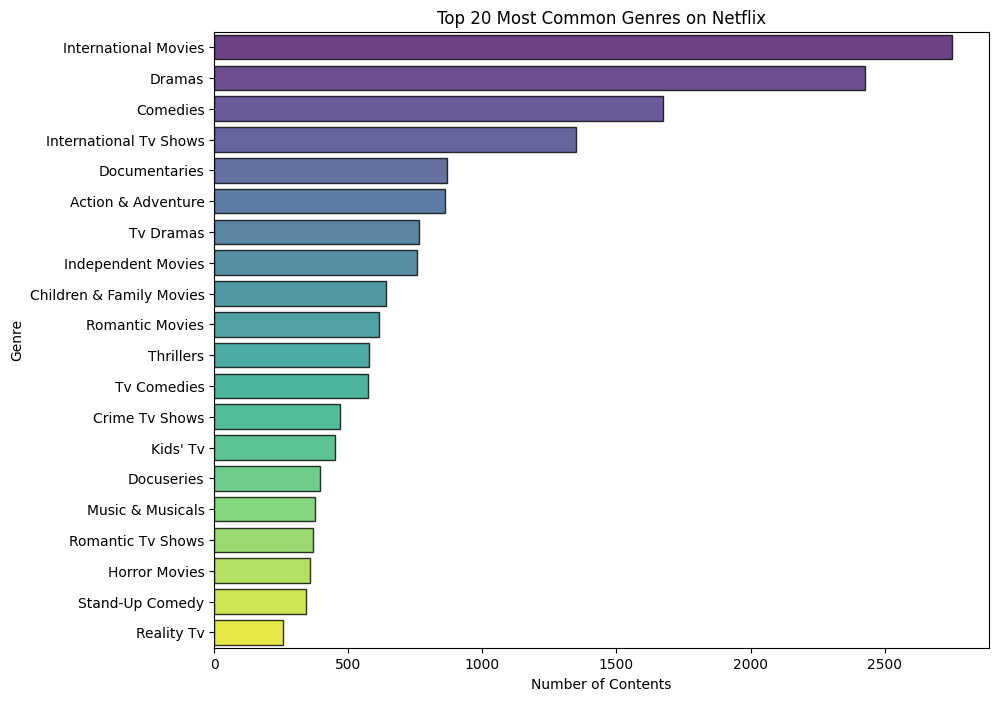

In [54]:
# plot the top 20 most common genres using a horizontal bar chart
plt.figure(figsize=(10, 8))
sns.barplot(data=top_genres, y="Listed In", x="Number of Contents", palette="viridis", edgecolor="black", saturation=1.5, alpha=0.8)
plt.title("Top 20 Most Common Genres on Netflix")
plt.xlabel("Number of Contents")
plt.ylabel("Genre")
plt.show()

### Observation

International Movies, Drama and Comedy-related genres are among the most common categories, indicating that Netflix offers a broad selection of dramatic and internationally produced content.